# Member B — TF-IDF Content Baseline

**Method**: Build TF-IDF vectors from news `title` + `abstract`. For each impression, compute the average TF-IDF vector of the user's click history as a *user profile*, then score each candidate by cosine similarity to that profile.

**Type**: Retrieval / Content-based  
**Dataset**: MIND-Small  
**Random seed**: 42  
**Metrics**: AUC, MRR, nDCG@5, nDCG@10

---

## Preprocessing Notes

| Decision | Choice | Reason |
|---|---|---|
| Text fields | `title + " " + title + " " + abstract` | Double-weight title (more signal-dense than abstract) |
| Tokenizer | sklearn default (unicode, `token_pattern=r"(?u)\b\w+\b"`) | Lightweight, no extra dependencies |
| Text cleaning | lowercase, strip punctuation (via TF-IDF `analyzer`) | Standard; keeps numbers |
| Stop words | English built-in (`sklearn`) | Removes noise words |
| `max_features` | 30,000 | Balances vocab coverage vs. memory |
| `ngram_range` | (1, 2) | Captures short phrases (e.g. "white house", "stock market") |
| `sublinear_tf` | True | Log-scale TF dampening, standard best practice |
| `min_df` | 2 | Filters hapax legomena (appears in only 1 doc) |
| Cold-start (empty history) | Score = 0.0 for all candidates | Neutral; no information to use |
| Scoring | Cosine similarity (user profile vector vs. candidate vector) | Standard for TF-IDF retrieval |

## 0. Imports & Config

In [3]:
import os
import json
import logging
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Paths ────────────────────────────────────────────────────────────────────
def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find project root from {start}. Expected a parent directory containing 'data'."
    )

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = find_project_root(NOTEBOOK_DIR)
TRAIN_DIR = str(PROJECT_ROOT / "data/train")
VALID_DIR = str(PROJECT_ROOT / "data/valid")
OUTPUT_DIR = str(NOTEBOOK_DIR / "tfidf_output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("train/news.tsv exists?", os.path.exists(os.path.join(TRAIN_DIR, "news.tsv")))

# ── Logging ──────────────────────────────────────────────────────────────────
log_path = os.path.join(OUTPUT_DIR, "run.log")
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)s  %(message)s",
    handlers=[
        logging.FileHandler(log_path, mode="w"),
        logging.StreamHandler()
    ]
)
log = logging.getLogger()
log.info("=== TF-IDF Content Baseline — start ===")

# ── TF-IDF hyper-params ───────────────────────────────────────────────────────
TFIDF_PARAMS = dict(
    max_features  = 30_000,
    ngram_range   = (1, 2),
    sublinear_tf  = True,
    min_df        = 2,
    stop_words    = "english",
    token_pattern = r"(?u)\b\w+\b",   # keeps single-char tokens too
)
log.info("TF-IDF params: %s", TFIDF_PARAMS)
print("Config OK")

2026-04-21 18:44:46,054  INFO  === TF-IDF Content Baseline — start ===
2026-04-21 18:44:46,054  INFO  TF-IDF params: {'max_features': 30000, 'ngram_range': (1, 2), 'sublinear_tf': True, 'min_df': 2, 'stop_words': 'english', 'token_pattern': '(?u)\\b\\w+\\b'}


PROJECT_ROOT: /Users/xiangningdeng/Desktop/2026 UCLA MDSH-Submit
train/news.tsv exists? True
Config OK


## 1. Load Data

In [4]:
NEWS_COLS = ["news_id","category","subcategory","title","abstract","url",
             "title_entities","abstract_entities"]
BEH_COLS  = ["impression_id","user_id","time","history","impressions"]

# Load both train and valid news so the vectorizer sees the full vocabulary
news_train = pd.read_csv(os.path.join(TRAIN_DIR, "news.tsv"),
                         sep="\t", header=None, names=NEWS_COLS)
news_valid = pd.read_csv(os.path.join(VALID_DIR, "news.tsv"),
                         sep="\t", header=None, names=NEWS_COLS)
news_all   = pd.concat([news_train, news_valid]).drop_duplicates("news_id").reset_index(drop=True)

beh_valid  = pd.read_csv(os.path.join(VALID_DIR, "behaviors.tsv"),
                         sep="\t", header=None, names=BEH_COLS)

log.info("News articles (combined): %d", len(news_all))
log.info("Validation impressions:   %d", len(beh_valid))

print(f"news_all shape : {news_all.shape}")
print(f"beh_valid shape: {beh_valid.shape}")
news_all.head(3)

2026-04-21 18:44:46,685  INFO  News articles (combined): 65238
2026-04-21 18:44:46,686  INFO  Validation impressions:   73152


news_all shape : (65238, 8)
beh_valid shape: (73152, 5)


,news_id,category,subcategory,title,abstract,url,title_entities,abstract_entities
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"",...",[]
1,N19639,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,https://assets.msn.com/labs/mind/AAB19MK.html,"[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...","[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik..."
2,N61837,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...,https://assets.msn.com/labs/mind/AAJgNsz.html,[],"[{""Label"": ""Ukraine"", ""Type"": ""G"", ""WikidataId..."


## 2. Text Preprocessing

In [5]:
def build_text(df: pd.DataFrame) -> pd.Series:
    """
    Concatenate title (doubled for extra weight) and abstract.
    Missing values are replaced with empty strings.
    """
    title    = df["title"].fillna("")
    abstract = df["abstract"].fillna("")
    return title + " " + title + " " + abstract   # title appears twice → higher TF weight

news_all["text"] = build_text(news_all)

# Quick sanity check
empty_text = (news_all["text"].str.strip() == "").sum()
log.info("Articles with empty text: %d", empty_text)
print(f"Empty text articles: {empty_text}")
print("Sample text:")
print(news_all["text"].iloc[0][:200])

2026-04-21 18:44:46,721  INFO  Articles with empty text: 0


Empty text articles: 0
Sample text:
The Brands Queen Elizabeth, Prince Charles, and Prince Philip Swear By The Brands Queen Elizabeth, Prince Charles, and Prince Philip Swear By Shop the notebooks, jackets, and more that the royals can'


## 3. Build TF-IDF Matrix

In [6]:
log.info("Fitting TF-IDF vectorizer...")

vectorizer = TfidfVectorizer(**TFIDF_PARAMS)
tfidf_matrix = vectorizer.fit_transform(news_all["text"])   # shape: (n_news, vocab)

# news_id → row index lookup
news_id_to_idx = {nid: i for i, nid in enumerate(news_all["news_id"])}

log.info("TF-IDF matrix shape: %s", tfidf_matrix.shape)
log.info("Vocabulary size: %d", len(vectorizer.vocabulary_))
print(f"TF-IDF matrix : {tfidf_matrix.shape}")
print(f"Vocabulary size: {len(vectorizer.vocabulary_):,}")

2026-04-21 18:44:46,725  INFO  Fitting TF-IDF vectorizer...
2026-04-21 18:44:49,512  INFO  TF-IDF matrix shape: (65238, 30000)
2026-04-21 18:44:49,512  INFO  Vocabulary size: 30000


TF-IDF matrix : (65238, 30000)
Vocabulary size: 30,000


## 4. Score Candidates (Validation Set)

In [7]:
def get_user_vector(history_str):
    """
    Average TF-IDF vectors of all news articles in the user's click history.
    Returns None if history is empty or contains no known news IDs.
    """
    if pd.isna(history_str) or str(history_str).strip() == "":
        return None
    ids = str(history_str).split()
    indices = [news_id_to_idx[nid] for nid in ids if nid in news_id_to_idx]
    if not indices:
        return None
    # Mean of sparse rows → dense
    return np.asarray(tfidf_matrix[indices].mean(axis=0))  # shape (1, vocab)


def score_impression(row):
    """
    Returns a list of dicts:
    {impression_id, news_id, label, score}
    """
    imp_id   = row["impression_id"]
    user_vec = get_user_vector(row["history"])
    records  = []

    for item in str(row["impressions"]).split():
        news_id, label = item.rsplit("-", 1)
        label = int(label)

        if user_vec is None or news_id not in news_id_to_idx:
            # Cold-start: no history or unknown news → score 0
            score = 0.0
        else:
            cand_vec = tfidf_matrix[news_id_to_idx[news_id]]     # sparse row
            score = float(cosine_similarity(user_vec, cand_vec)[0, 0])

        records.append({
            "impression_id" : imp_id,
            "news_id"       : news_id,
            "label"         : label,
            "score"         : score,
        })
    return records


log.info("Scoring validation impressions...")
all_records = []
for _, row in beh_valid.iterrows():
    all_records.extend(score_impression(row))

pred_df = pd.DataFrame(all_records)
log.info("Total scored candidates: %d", len(pred_df))
print(f"Total scored rows: {len(pred_df):,}")
print(f"Label distribution:\n{pred_df['label'].value_counts()}")
pred_df.head()

2026-04-21 18:44:49,517  INFO  Scoring validation impressions...
2026-04-21 18:52:14,856  INFO  Total scored candidates: 2740998


Total scored rows: 2,740,998
Label distribution:
label
0    2629615
1     111383
Name: count, dtype: int64


,impression_id,news_id,label,score
0,1,N28682,0,0.011100
1,1,N48740,0,0.034688
2,1,N31958,1,0.013953
3,1,N34130,0,0.006413
4,1,N6916,0,0.019698


## 5. Evaluation

In [8]:
# ── Metric helpers ────────────────────────────────────────────────────────────

def dcg_at_k(labels_sorted: np.ndarray, k: int) -> float:
    """Discounted Cumulative Gain at position k (log2 base)."""
    labels_k = labels_sorted[:k]
    if len(labels_k) == 0:
        return 0.0
    gains    = labels_k / np.log2(np.arange(2, len(labels_k) + 2))
    return gains.sum()


def ndcg_at_k(labels: np.ndarray, scores: np.ndarray, k: int) -> float:
    """Normalized DCG@k."""
    order         = np.argsort(-scores)
    labels_sorted = labels[order]
    ideal_sorted  = np.sort(labels)[::-1]
    idcg          = dcg_at_k(ideal_sorted, k)
    if idcg == 0:
        return 0.0
    return dcg_at_k(labels_sorted, k) / idcg


def mrr(labels: np.ndarray, scores: np.ndarray) -> float:
    """Mean Reciprocal Rank (reciprocal rank of first relevant item)."""
    order  = np.argsort(-scores)
    hits   = np.where(labels[order] == 1)[0]
    if len(hits) == 0:
        return 0.0
    return 1.0 / (hits[0] + 1)


# ── Per-impression evaluation ─────────────────────────────────────────────────

def evaluate(df: pd.DataFrame) -> dict:
    """
    Compute AUC, MRR, nDCG@5, nDCG@10 averaged over all impressions.
    Impressions with no positive label are skipped for AUC.
    """
    auc_list    = []
    mrr_list    = []
    ndcg5_list  = []
    ndcg10_list = []

    for imp_id, grp in df.groupby("impression_id"):
        labels = grp["label"].values.astype(float)
        scores = grp["score"].values

        if labels.sum() == 0 or labels.sum() == len(labels):
            pass  # skip AUC (undefined), still compute ranking metrics
        else:
            auc_list.append(roc_auc_score(labels, scores))

        mrr_list.append(mrr(labels, scores))
        ndcg5_list.append(ndcg_at_k(labels, scores, k=5))
        ndcg10_list.append(ndcg_at_k(labels, scores, k=10))

    return {
        "AUC"      : float(np.mean(auc_list))    if auc_list    else None,
        "MRR"      : float(np.mean(mrr_list)),
        "nDCG@5"   : float(np.mean(ndcg5_list)),
        "nDCG@10"  : float(np.mean(ndcg10_list)),
        "n_impressions": len(df["impression_id"].unique()),
        "n_auc_valid"  : len(auc_list),
    }


log.info("Computing metrics...")
metrics = evaluate(pred_df)
metrics["method"] = "tfidf"

for k, v in metrics.items():
    if isinstance(v, float):
        log.info("  %-20s %.4f", k, v)
    else:
        log.info("  %-20s %s", k, v)

print("\n" + "="*40)
print("   TF-IDF Content Baseline — Results")
print("="*40)
for k, v in metrics.items():
    if isinstance(v, float):
        print(f"  {k:<20} {v:.4f}")
    else:
        print(f"  {k:<20} {v}")
print("="*40)

2026-04-21 18:52:14,870  INFO  Computing metrics...
2026-04-21 18:52:40,481  INFO    AUC                  0.5656
2026-04-21 18:52:40,482  INFO    MRR                  0.3154
2026-04-21 18:52:40,482  INFO    nDCG@5               0.2882
2026-04-21 18:52:40,482  INFO    nDCG@10              0.3513
2026-04-21 18:52:40,483  INFO    n_impressions        73152
2026-04-21 18:52:40,483  INFO    n_auc_valid          73152
2026-04-21 18:52:40,483  INFO    method               tfidf



   TF-IDF Content Baseline — Results
  AUC                  0.5656
  MRR                  0.3154
  nDCG@5               0.2882
  nDCG@10              0.3513
  n_impressions        73152
  n_auc_valid          73152
  method               tfidf


## 6. Save Outputs

In [9]:
# ── metrics.json ──────────────────────────────────────────────────────────────
metrics_path = os.path.join(OUTPUT_DIR, "metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)
log.info("Saved metrics → %s", metrics_path)

# ── prediction.txt ────────────────────────────────────────────────────────────
# Format: impression_id \t news_id \t label \t score
pred_path = os.path.join(OUTPUT_DIR, "prediction.txt")
pred_df.to_csv(pred_path, sep="\t", index=False)
log.info("Saved predictions → %s", pred_path)

print(f"\nOutputs written to: {OUTPUT_DIR}/")
print(f"  metrics.json    — {metrics_path}")
print(f"  prediction.txt  — {pred_path}")
print(f"  run.log         — {log_path}")

2026-04-21 18:52:40,488  INFO  Saved metrics → /Users/xiangningdeng/Desktop/2026 UCLA MDSH-Submit/round1_baselines/tfidf_output/metrics.json
2026-04-21 18:52:42,431  INFO  Saved predictions → /Users/xiangningdeng/Desktop/2026 UCLA MDSH-Submit/round1_baselines/tfidf_output/prediction.txt



Outputs written to: /Users/xiangningdeng/Desktop/2026 UCLA MDSH-Submit/round1_baselines/tfidf_output/
  metrics.json    — /Users/xiangningdeng/Desktop/2026 UCLA MDSH-Submit/round1_baselines/tfidf_output/metrics.json
  prediction.txt  — /Users/xiangningdeng/Desktop/2026 UCLA MDSH-Submit/round1_baselines/tfidf_output/prediction.txt
  run.log         — /Users/xiangningdeng/Desktop/2026 UCLA MDSH-Submit/round1_baselines/tfidf_output/run.log


## 7. Quick Sanity Checks

Clicked    — mean: 0.0307  median: 0.0200
Not-clicked — mean: 0.0206  median: 0.0148
Cold-start fraction: 15.56%


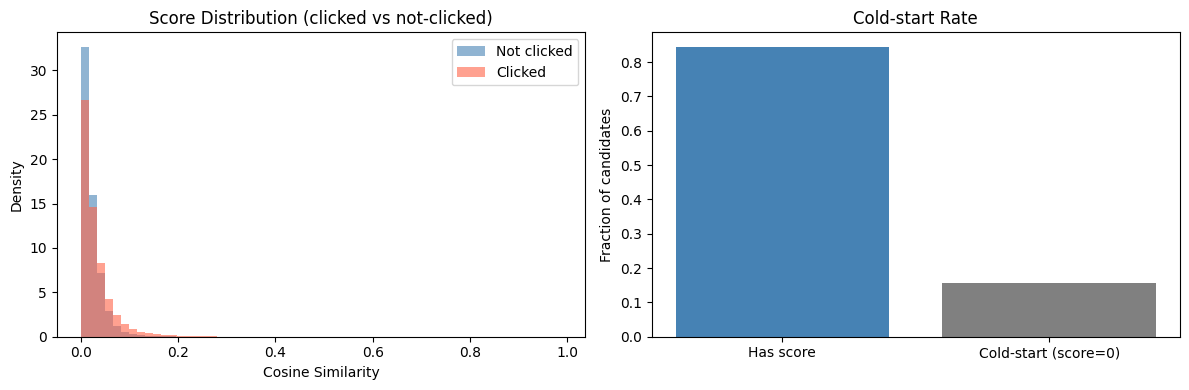

2026-04-21 18:52:43,237  INFO  Saved score distribution plot


In [10]:
# 7a. Score distribution — clicked vs not-clicked
import matplotlib.pyplot as plt

click    = pred_df[pred_df["label"] == 1]["score"]
no_click = pred_df[pred_df["label"] == 0]["score"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(no_click, bins=60, alpha=0.6, label="Not clicked", color="steelblue", density=True)
axes[0].hist(click,    bins=60, alpha=0.6, label="Clicked",     color="tomato",    density=True)
axes[0].set_title("Score Distribution (clicked vs not-clicked)")
axes[0].set_xlabel("Cosine Similarity")
axes[0].set_ylabel("Density")
axes[0].legend()

print(f"Clicked    — mean: {click.mean():.4f}  median: {click.median():.4f}")
print(f"Not-clicked — mean: {no_click.mean():.4f}  median: {no_click.median():.4f}")

# 7b. Cold-start proportion
zero_score = (pred_df["score"] == 0.0).mean()
axes[1].bar(["Has score", "Cold-start (score=0)"], [1 - zero_score, zero_score],
            color=["steelblue", "grey"])
axes[1].set_title("Cold-start Rate")
axes[1].set_ylabel("Fraction of candidates")
print(f"Cold-start fraction: {zero_score:.2%}")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "score_distribution.png"), dpi=120)
plt.show()
log.info("Saved score distribution plot")

In [11]:
# 7c. Top-20 vocabulary terms by average IDF weight
idf_series = pd.Series(
    vectorizer.idf_,
    index=vectorizer.get_feature_names_out()
).sort_values(ascending=False)

print("Top-20 highest-IDF terms (most distinctive):")
print(idf_series.head(20).to_string())
print("\nTop-20 lowest-IDF terms (most common, near stop-words):")
print(idf_series.tail(20).to_string())

Top-20 highest-IDF terms (most distinctive):
gund                10.987200
shane q             10.699518
south windsor       10.699518
cheshire            10.699518
elsberry            10.699518
phanatic            10.699518
raine               10.699518
bublé               10.699518
ile                 10.699518
santikos            10.699518
bianco              10.699518
sherwin williams    10.699518
sherwin             10.699518
smithville          10.699518
diablo iv           10.699518
lynden              10.699518
muay                10.699518
muay thai           10.699518
burge               10.699518
oberlin             10.476375

Top-20 lowest-IDF terms (most common, near stop-words):
home         3.997558
1            3.992656
according    3.984741
says         3.979600
trump        3.972087
night        3.915344
old          3.909702
m            3.907735
just         3.861917
police       3.840166
season       3.837022
time         3.791013
game         3.786776
state       

In [12]:
# 7d. Example: inspect one impression
sample = beh_valid.iloc[1]   # impression_id = 2
print("Impression:", sample["impression_id"])
print("History   :", str(sample["history"])[:120])
print()

imp_rows = pred_df[pred_df["impression_id"] == sample["impression_id"]].copy()
imp_rows = imp_rows.sort_values("score", ascending=False)
# Join title for readability
imp_rows = imp_rows.merge(news_all[["news_id","title","category"]], on="news_id", how="left")
print(imp_rows[["news_id","label","score","category","title"]].to_string(index=False))

Impression: 2
History   : N58715 N32109 N51180 N33438 N54827 N28488 N61186 N34775 N33742 N50020 N57061 N30924 N6778

news_id  label    score     category                                                                                                     title
 N36779      0 0.025035         news                             South Carolina teen gets life in prison for deadly elementary school shooting
 N35216      0 0.021833    lifestyle                                                             Queen Elizabeth Just Rode Horseback at Age 93
 N31958      0 0.014171       sports                                      Opinion: Colin Kaepernick is about to get what he deserves: a chance
 N20036      0 0.012328    lifestyle                                                                    30 Best Black Friday Deals from Costco
 N32536      0 0.008803      weather                                               High tides surge through Venice, locals rush to protect art
 N23513      1 0.005789  

## 8. Summary

| Metric | Value |
|--------|-------|
| AUC | see `metrics.json` |
| MRR | see `metrics.json` |
| nDCG@5 | see `metrics.json` |
| nDCG@10 | see `metrics.json` |

**Limitations of this approach:**
- No semantic understanding — "NBA" and "basketball" are different tokens
- No collaborative signal — purely content-based
- Cold-start users (empty history) get score = 0

**Output files:**
- `round1_baselines/tfidf_output/metrics.json` — evaluation metrics
- `round1_baselines/tfidf_output/prediction.txt` — `(impression_id, news_id, label, score)` per candidate row
- `round1_baselines/tfidf_output/run.log` — full execution log
- `round1_baselines/tfidf_output/score_distribution.png` — click vs no-click score histograms